## Avancerade Pandas-mönster & mer prestandatänk

### Agenda

1. **Avancerade Pandas-mönster**:
   - `query` och `eval` för filtrering och nya kolumner
   - Method chaining och `assign`
   - Pipelines med `pipe`
   - Fönsterfunktioner: `shift`, `diff`, `rolling`
2. **Prestanda, del II**:
   - Lite mer om minne, `copy()` och chunkad läsning
3. **Lite om vad som finns efter Pandas** – bara namn-droppning:
   - Polars, DuckDB, Dask, Spark, databaser…
   - När man brukar börja titta på dem

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ställ in så att Pandas skriver ut lite fler kolumner/kolumnbredd
#pd.set_option("display.max_columns", 20)
#pd.set_option("display.width", 120)

---
## 1. Avancerade Pandas-mönster

I det här avsnittet tittar vi på mönster som du **redan nästan kan**, men där vi gör koden:

- mer **läsbar**
- mer **kompakt**
- mer lik en **datapipeline**

Vi börjar med ett litet **syntetiskt sälj-dataset** som vi kan återanvända i flera exempel.


In [2]:
# Skapa ett litet syntetiskt "sales"-dataset
products = ["Laptop", "Phone", "Tablet", "Headphones", "Monitor"]
countries = ["SE", "NO", "DK", "FI", "DE"]

n_rows = 200

sales_df = pd.DataFrame({
                            "OrderID": range(1, n_rows + 1),
                            "ProductName": [random.choice(products) for _ in range(n_rows)],
                            "Country": [random.choice(countries) for _ in range(n_rows)],
                            "Price": [random.randint(500, 14999) for _ in range(n_rows)],   
                            "Quantity": [random.randint(1, 4) for _ in range(n_rows)],
                            "OrderDate": pd.to_datetime("2025-01-01") + pd.to_timedelta([random.randint(0, 89) for _ in range(n_rows)], unit='D')
                            
})

sales_df.head(10)

,OrderID,ProductName,Country,Price,Quantity,OrderDate
0,1,Tablet,FI,13394,4,2025-03-14
1,2,Tablet,DE,4524,2,2025-01-16
2,3,Headphones,NO,1417,3,2025-02-16
3,4,Monitor,FI,7669,1,2025-02-18
4,5,Phone,SE,2226,4,2025-02-15
5,6,Tablet,DK,5283,2,2025-03-21
6,7,Headphones,DE,6106,1,2025-01-13
7,8,Tablet,FI,8211,1,2025-03-03
8,9,Monitor,FI,13192,3,2025-03-28
9,10,Monitor,FI,771,4,2025-02-01


---

### 1.1 `query` och `eval` – snyggare uttryck

Innan vi går in på method chaining ska vi titta på två verktyg som ofta dyker upp där:

- `query` – för att filtrera rader med en liten sträng
- `eval` – för att skapa/uppdatera kolumner med ett uttryck

#### `query` för filtrering

`query` låter dig skriva filter som en liten sträng, vilket ibland blir mer läsbart än många `&` och `|`.


In [3]:
# filtrera fram svenska ordrar med pris > 5000 och kvantitet minst 2

# metod 1 med query 

sales_df.query("Country == 'SE' and Price > 5000 and Quantity >= 2")

,OrderID,ProductName,Country,Price,Quantity,OrderDate
33,34,Headphones,SE,5851,2,2025-02-03
45,46,Headphones,SE,6030,2,2025-02-16
48,49,Headphones,SE,6341,2,2025-01-22
58,59,Headphones,SE,14324,2,2025-03-29
66,67,Tablet,SE,8788,3,2025-01-20
80,81,Tablet,SE,12723,2,2025-02-13
97,98,Monitor,SE,6011,2,2025-02-07
102,103,Tablet,SE,11415,4,2025-03-04
104,105,Phone,SE,12917,4,2025-03-28
118,119,Phone,SE,5385,3,2025-03-16


In [4]:
# metod 2 med query, återanvändbara filter

sweden_filter = "Country =='SE'"
price_filter = "Price > 5000"
quantity_filter = "Quantity >= 2"

sales_df.query(f'{sweden_filter} and {price_filter} and {quantity_filter}')

,OrderID,ProductName,Country,Price,Quantity,OrderDate
33,34,Headphones,SE,5851,2,2025-02-03
45,46,Headphones,SE,6030,2,2025-02-16
48,49,Headphones,SE,6341,2,2025-01-22
58,59,Headphones,SE,14324,2,2025-03-29
66,67,Tablet,SE,8788,3,2025-01-20
80,81,Tablet,SE,12723,2,2025-02-13
97,98,Monitor,SE,6011,2,2025-02-07
102,103,Tablet,SE,11415,4,2025-03-04
104,105,Phone,SE,12917,4,2025-03-28
118,119,Phone,SE,5385,3,2025-03-16


Detta motsvarar ungefär:

```python
sales_df[
    (sales_df["Country"] == "SE")
    & (sales_df["Price"] > 5000)
    & (sales_df["Quantity"] >= 2)
]
```

Båda varianterna är korrekta – välj den du tycker är tydligast.

#### `eval` för nya kolumner

`eval` låter dig beräkna uttryck på kolumner med en strängsyntax:

In [5]:
eval_df = sales_df.copy()

eval_df.eval("revenue = Price * Quantity", inplace=True)
eval_df.head()

,OrderID,ProductName,Country,Price,Quantity,OrderDate,revenue
0,1,Tablet,FI,13394,4,2025-03-14,53576
1,2,Tablet,DE,4524,2,2025-01-16,9048
2,3,Headphones,NO,1417,3,2025-02-16,4251
3,4,Monitor,FI,7669,1,2025-02-18,7669
4,5,Phone,SE,2226,4,2025-02-15,8904


> I vissa fall kan `query`/`eval` också vara snabbare än motsvarande "vanliga" kod, men den största vinsten är ofta **läsbarhet**.


---
### 1.2 Intro till: `.agg` och `lambda`

#### `.agg` – aggregera värden

`agg` låter dig räkna ut sammanfattande mått, t.ex. medelvärde och maxvärde för en kolumn:

In [9]:
# enkel .agg på en Series

# sales_df['Price'].mean()

sales_df['Price'].agg(['mean'])

mean    7875.11
Name: Price, dtype: float64

In [10]:
sales_df['Price'].agg(['mean', 'max', 'min', 'sum'])

mean       7875.11
max       14940.00
min         512.00
sum     1575022.00
Name: Price, dtype: float64

Vi kan också använda `agg` efter en `groupby` för att ge namn åt beräknade kolumner:

In [18]:
sales_df.groupby('Country').agg(
                                total_sales=('Price', 'sum'),
                                avg_quantity=('Quantity', 'mean'))

,total_sales,avg_quantity
Country,,
DE,386856,2.760000
DK,321158,2.341463
FI,366468,2.558140
NO,220809,2.535714
SE,279731,2.605263


Där t.ex. `total_sales=("Price", "sum")` betyder:

- skapa en kolumn som heter `total_sales`
- beräkna den genom att ta `sum` av kolumnen `"Price"` inom varje grupp.

#### `lambda` – små funktioner "i farten"

En `lambda` är ett sätt att skriva en **liten funktion på en rad**.

Med vanlig funktion:

In [20]:
def add_vat(price):

    return price * 1.25

sales_df['Price_with_vat_def'] = sales_df['Price'].apply(add_vat)

sales_df.head()

,OrderID,ProductName,Country,Price,Quantity,OrderDate,Price_with_vat_def
0,1,Tablet,FI,13394,4,2025-03-14,16742.50
1,2,Tablet,DE,4524,2,2025-01-16,5655.00
2,3,Headphones,NO,1417,3,2025-02-16,1771.25
3,4,Monitor,FI,7669,1,2025-02-18,9586.25
4,5,Phone,SE,2226,4,2025-02-15,2782.50


Samma sak med lambda:

In [25]:
sales_df['Price_with_vat_lambda'] =sales_df['Price'].apply(lambda x: x * 1.25)

sales_df.head()

,OrderID,ProductName,Country,Price,Quantity,OrderDate,Price_with_vat_def,Price_with_vat_lambda
0,1,Tablet,FI,13394,4,2025-03-14,16742.50,16742.50
1,2,Tablet,DE,4524,2,2025-01-16,5655.00,5655.00
2,3,Headphones,NO,1417,3,2025-02-16,1771.25,1771.25
3,4,Monitor,FI,7669,1,2025-02-18,9586.25,9586.25
4,5,Phone,SE,2226,4,2025-02-15,2782.50,2782.50


`lambda x: x * 1.25` betyder ungefär "en funktion med ett argument `x` som returnerar `x * 1.25`".


---
### 1.3 Method chaining & `assign`

Ofta skriver vi Pandas-kod steg för steg, t.ex. så här:

In [28]:
# Klassisk steg-för-steg metodik

df = sales_df.copy()

# 1. Byt namn på kolumn
df = df.rename(columns={'ProductName': 'product'})

# 2. Filtrera bort orimliga priser
df = df[ df['Price'] > 0 ]

# 3. Räkna ut intäkt mer rad
df['revenue'] = df['Price'] * df['Quantity']

# 4. Summera intäkter per produkt
results_step_by_step = df.groupby('product')['revenue'].sum()

results_step_by_step

product
Headphones    912608
Laptop        715740
Monitor       754249
Phone         649564
Tablet        957725
Name: revenue, dtype: int64

Det här funkar jättebra, men blir snabbt långt när vi lägger till många steg.

Med **method chaining** låter vi i stället `DataFrame` flöda genom en kedja av metoder. Det gör det lättare att läsa processen uppifrån och ned.

Vi använder främst:

- `rename` för att byta kolumnnamn
- `query` för filtrering
- `assign` för att lägga till nya kolumner
- `groupby(..).agg(..)` för sammanställning


In [ ]:
# Samma logik som ovan, men med method chaining

result_chained_df = ( 
                    sales_df
                    .rename(columns={'ProductName': 'product'})
                    .query('Price > 0')
                    .assign(revenue = lambda x: x['Price'] * x['Quantity'])
                    .groupby('product', as_index=False)
                    .agg(total_revenue=("revenue", "sum"), 
                        avg_price=("Price", "mean"))
)

result_chained_df

,product,total_revenue,avg_price
0,Headphones,912608,7493.823529
1,Laptop,715740,7721.973684
2,Monitor,754249,7994.638889
3,Phone,649564,7579.970588
4,Tablet,957725,8631.121951


---
### 1.4 `pipe` och enkla pipelines

När kedjan blir längre kan det vara skönt att dela upp logiken i **små funktioner** som var och en gör en sak, och sedan koppla ihop dem med `pipe`.

Tanken med `pipe` är:

> Ta en DataFrame → skicka in den i en funktion → få ut en ny DataFrame → fortsätt kedjan.

In [ ]:
def filter_positive_price(df):
    """Filtrera bort rader med pris <= 0"""

    return df[df['Price']>0]

def add_revenue(df):
    """Lägg till en revenue kolumn (Price*Quantity)"""

    df['revenue'] = df["Price"] * df['Quantity']

    return df

def aggregate_by_product(df):
    """Summera intäkter per kolumn"""

    return (
            df.groupby("ProductName")
            .agg(total_revenue=("revenue", "sum"))
            )

In [42]:
# Bygg en pipeline med pipe

pipeline_results_df = (
                       sales_df
                       .pipe(filter_positive_price)
                       .pipe(add_revenue)
                       .pipe(aggregate_by_product)
                       )

pipeline_results_df

,total_revenue
ProductName,
Headphones,912608
Laptop,715740
Monitor,754249
Phone,649564
Tablet,957725


Fördelar med att använda `pipe` och små funktioner:

- Varje funktion gör **en tydlig sak**.
- Lättare att återanvända samma steg i andra analyser.
- Koden liknar ett **flöde**: inläsning → filtrering → beräkning → aggregering.

> **Tips:** Du kan börja med vanlig "steg-för-steg"-kod, och när du märker att du gör samma sak på flera ställen – bryt ut det till en funktion och använd `pipe`.

---
### 1.5 Fönsterfunktioner: `shift`, `diff`, `rolling`

Låt oss skapa en enkel tidsserie: daglig "site visits" (t.ex. antal besök på en webbsida).


In [66]:
# Skapa en syntetisk tidsserie med dagliga värden
dates = pd.date_range("2025-01-01", periods=60, freq="D")

# Vi bygger en "random walk" med Python's random.gauss
visits = []
value = 100

for _ in range(len(dates)):
    value += int(random.gauss(0.5, 5))  # slumpmässig förändring
    visits.append(value)

traffic_df = pd.DataFrame({"date": dates, "visits": visits})
traffic_df.head()

,date,visits
0,2025-01-01,98
1,2025-01-02,98
2,2025-01-03,100
3,2025-01-04,96
4,2025-01-05,97


Vi sorterar på datum (bra vana) och använder tre viktiga metoder:

- `.shift(n)` – flyttar värden upp/ned (t.ex. gårdagens värde)
- `.diff()` – skillnad mot föregående rad
- `.rolling(window)` – "rörligt fönster", t.ex. 7-dagars medelvärde


In [67]:
traffic_df = traffic_df.sort_values('date').reset_index(drop=True)

traffic_df['visits_prev_day'] = traffic_df['visits'].shift(1)
traffic_df['change_from_prev_day'] = traffic_df['visits'].diff()
traffic_df['rolling_7d_mean'] = traffic_df['visits'].rolling(7).mean()

traffic_df.head(10)

,date,visits,visits_prev_day,change_from_prev_day,rolling_7d_mean
0,2025-01-01,98,NaN,NaN,NaN
1,2025-01-02,98,98.0,0.0,NaN
2,2025-01-03,100,98.0,2.0,NaN
3,2025-01-04,96,100.0,-4.0,NaN
4,2025-01-05,97,96.0,1.0,NaN
5,2025-01-06,95,97.0,-2.0,NaN
6,2025-01-07,98,95.0,3.0,97.428571
7,2025-01-08,98,98.0,0.0,97.428571
8,2025-01-09,102,98.0,4.0,98.000000
9,2025-01-10,110,102.0,8.0,99.428571


Vi kan också göra en enkel plot för att se originalserien och 7-dagarsmedelvärdet:

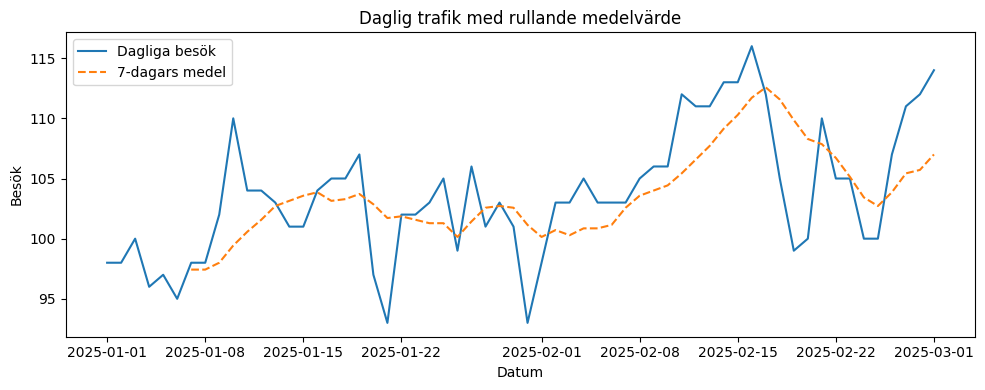

In [69]:
plt.figure(figsize=(10, 4))
plt.plot(traffic_df['date'], traffic_df['visits'], label='Dagliga besök')
plt.plot(traffic_df['date'], traffic_df['rolling_7d_mean'], label='7-dagars medel', linestyle="--")
plt.xlabel('Datum')
plt.ylabel('Besök')
plt.title('Daglig trafik med rullande medelvärde')
plt.legend()
plt.tight_layout()
plt.show()

> **Reflektion:** Fönsterfunktioner är väldigt användbara för tidsserier – du kan t.ex. jämna ut brus, räkna förändringar, eller jämföra mot gårdagens/förra veckans värden.


---
## 2. Prestanda i Pandas – Del II

Du har redan sett att:

- `for`-loopar över rader är långsamma
- `iterrows()` och `apply(axis=1)` ofta är betydligt långsammare än vektoriserade operationer

Nu tittar vi på ytterligare tips på minneseffektivisering.


---

### 2.1 Datatyper

#### Viktigt att använda lämpligast datatyp baserat på behov

In [73]:
# Titta på unika länder

sales_df['Country'].value_counts()

Country
DE    50
FI    43
DK    41
SE    38
NO    28
Name: count, dtype: int64

In [74]:
sales_df['Country'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 200 entries, 0 to 199
Series name: Country
Non-Null Count  Dtype 
--------------  ----- 
200 non-null    object
dtypes: object(1)
memory usage: 1.7+ KB


In [76]:
# Gör om Country till category

sales_df['Country'] = sales_df['Country'].astype("category")

sales_df['Country'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 200 entries, 0 to 199
Series name: Country
Non-Null Count  Dtype   
--------------  -----   
200 non-null    category
dtypes: category(1)
memory usage: 544.0 bytes


`category`-kolumner:

- tar mindre plats i minnet
- kan ge snabbare groupby/join i vissa fall

---
### 2.2 Minne, `copy()` och chunkad läsning

#### a) Hur mycket minne använder en DataFrame?

Vi har tidigare sett hur man evaluera minnesanvändning per kolumn med `memory_usage`:

In [77]:
sales_df.memory_usage(deep=True)

Index                      132
OrderID                   1600
ProductName              11206
Country                    627
Price                     1600
Quantity                  1600
OrderDate                 1600
Price_with_vat_def        1600
Price_with_vat_lambda     1600
dtype: int64

In [ ]:
total_bytes = sales_df.memory_usage(deep=True).sum()

total_mb = round(total_bytes / 1024 ** 2, 3)
print(f'Total minnesanvädning för sales_df: {total_mb} MB')

Total minnesanvädning för sales_df: 0.021 MB


> `memory_usage` ger antal **byte**. Vi delar med `1024 ** 2` för att få **megabyte (MB)**.

#### b) `copy()` – när och varför?

När vi gör en filtrering får vi ofta en *view* eller *kopia* beroende på situationen. För att undvika oväntade effekter är det ofta bra att göra en explicit `copy()` *när du planerar att ändra i den nya DataFramen*:

In [82]:
sweden_sales_df = sales_df[ sales_df['Country']=='SE'].copy()

sweden_sales_df['Price_with-tax'] = sweden_sales_df['Price'] * 1.25
sweden_sales_df.head()

,OrderID,ProductName,Country,Price,Quantity,OrderDate,Price_with_vat_def,Price_with_vat_lambda,Price_with-tax
4,5,Phone,SE,2226,4,2025-02-15,2782.50,2782.50,2782.50
15,16,Tablet,SE,3560,3,2025-01-18,4450.00,4450.00,4450.00
24,25,Tablet,SE,4923,1,2025-03-02,6153.75,6153.75,6153.75
25,26,Headphones,SE,3170,4,2025-02-16,3962.50,3962.50,3962.50
28,29,Headphones,SE,620,3,2025-01-20,775.00,775.00,775.00


Vi använder `.copy()` för att säga "det här är en egen tabell som jag tänker ändra i".

Men vi vill inte göra **onödigt många** kopior, eftersom det kostar minne och tid.


#### c) Chunkad läsning – när filen är stor

Ibland är en CSV-fil så stor att det är jobbigt att läsa in allt på en gång. Då kan vi läsa den i **chunkar** (bitar) med `chunksize`.

Här skapar vi först en syntetisk "stor" DataFrame och sparar den till disk, bara för att illustrera idén. I verkligheten skulle du ha en stor fil redan.

In [83]:
# Skapa en syntetisk "stor" DataFrame och spara som CSV
# (Här har vi ett ganska litet antal rader för att notebooken ska gå snabbt att köra)
n_big = 200_000

big_values = [random.gauss(100, 15) for _ in range(n_big)]

big_df = pd.DataFrame({
    "id": range(n_big),
    "value": big_values,
})

big_df.head()

,id,value
0,0,114.411372
1,1,89.646438
2,2,124.906036
3,3,83.879618
4,4,84.151091


In [89]:
big_df['value'].sum()

np.float64(19995128.250113793)

In [84]:
csv_path = 'big_synthetic_data.csv'

big_df.to_csv(csv_path, index=False)

In [ ]:
# Läs in filen i chunkar och summera value-kolumnen för varje sådan chunk

total = 0
chunk_size = 1000

for df in pd.read_csv(csv_path, chunksize=chunk_size):

    total += df['value'].sum()


print(f'Total summa av value-kolumn: {total}')

Total summa av value-kolumn: 19995128.250113796


Idén här är:

- Vi läser bara in `chunk_size` rader åt gången i minnet.
- Vi gör en enkel beräkning per chunk (t.ex. `sum`, `mean`, `groupby`).
- Vi ackumulerar resultatet över alla chunkar.

På så sätt kan vi ofta hantera dataset som är **större än datorns minne**, så länge vi bara behöver aggregerad information.


---

## 3. Kort om livet efter Pandas

Den här kursen har fokuserat på **Pandas**, och det räcker långt i verkliga projekt.

Men det är bra att känna till att det finns andra verktyg i samma "familj". Här är en **mycket kort** översikt.

### 3.1 När börjar Pandas kännas jobbigt?

Typiska situationer:

- Ditt dataset är så stort att det **knappt får plats i minnet** (eller inte alls).
- En enkel `groupby` eller `merge` tar **många minuter** att köra.
- Du vill köra samma typ av analys om och om igen på enorma datamängder.
- Du vill utnyttja **alla CPU-kärnor** på ett mer automatiskt sätt.

Då kan man börja titta på andra verktyg.

### 3.2 Olika typer av verktyg (bara exempel)

Du behöver inte komma ihåg detaljerna – tanken är bara att du ska känna igen namnen senare.

- **Andra DataFrame-bibliotek (liknar Pandas):**
  - *Polars* – modernt, kolumnorienterat, skrivet i Rust, fokuserat på hastighet.
  - https://pola.rs/

- **"SQL-motorer" för analyser direkt på filer:**
  - *DuckDB* – kan köra SQL-frågor direkt mot t.ex. CSV/Parquet-filer.

- **Storskaliga system (kluster / flera datorer):**
  - *Dask* – skalar upp Pandas-liknande kod till flera kärnor/maskiner.
  - *Apache Spark* – mycket vanligt i "big data"-miljöer.

- **Databaser:**
  - t.ex. PostgreSQL, MySQL, SQLite
  - Kombineras ofta med Pandas: lagra data i databasen → hämta ett urval in i en DataFrame för analys.


### 3.3 Det viktigaste: din mentala modell följer med

Oavsett om du fortsätter med Pandas eller stöter på andra verktyg senare, är grunderna **samma**:

- tabeller med rader och kolumner
- filtrering
- `groupby`-tänk: grupper + aggregat
- `join`/`merge`: koppla ihop tabeller
- tidserier med datum/tider
- vektoriserat tänk i stället för rad-för-rad-loopar

Det du har lärt dig här är alltså **inte bortkastat**. Tvärtom, det är **mycket relevant** även om du en dag jobbar med helt andra verktyg.